In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer  #preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif #Feature Selection

from sklearn.model_selection import train_test_split #Split dataset

from sklearn.ensemble import RandomForestClassifier  #classification 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,  
    
    roc_curve
)
import joblib #Save model

In [87]:
import pandas as pd

df = pd.read_csv("sepsis_detection_cleaned_dataset.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [88]:
X = df.drop("SepsisLabel", axis=1)

y = df["SepsisLabel"]

print("X and y created")

X and y created


In [89]:
print(df.shape)
print(df.columns)

(546123, 13)
Index(['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender',
       'ICULOS', 'HospAdmTime', 'Glucose', 'SepsisLabel'],
      dtype='str')


In [90]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 546123 entries, 0 to 546122
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   HR           546123 non-null  float64
 1   O2Sat        546123 non-null  float64
 2   Temp         546123 non-null  float64
 3   SBP          546123 non-null  float64
 4   MAP          546123 non-null  float64
 5   DBP          546123 non-null  float64
 6   Resp         546123 non-null  float64
 7   Age          546123 non-null  float64
 8   Gender       546123 non-null  float64
 9   ICULOS       546123 non-null  float64
 10  HospAdmTime  546123 non-null  float64
 11  Glucose      546123 non-null  float64
 12  SepsisLabel  546123 non-null  float64
dtypes: float64(13)
memory usage: 54.2 MB


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,Gender,ICULOS,HospAdmTime,Glucose,SepsisLabel
count,546123.000000,546123.000000,546123.000000,546123.000000,546123.000000,546123.000000,546123.000000,546123.000000,546123.000000,546123.000000,546123.000000,546123.000000,546123.000000
mean,84.864273,97.347907,37.049255,120.777712,78.675525,59.574495,18.675796,63.008409,0.577183,27.159955,-52.003906,125.184981,0.021698
std,16.269627,2.763330,0.455495,19.815053,14.281939,9.121977,5.114607,16.150150,0.494007,28.070814,148.651442,18.216441,0.145697
min,20.000000,20.000000,21.000000,22.000000,20.000000,20.000000,1.000000,18.110000,0.000000,1.000000,-3710.660000,10.000000,0.000000
25%,74.000000,96.000000,37.060000,108.000000,69.330000,58.000000,15.000000,52.670000,0.000000,11.000000,-38.010000,124.000000,0.000000
50%,84.000000,98.000000,37.060000,119.000000,77.000000,59.000000,18.000000,65.270000,1.000000,21.000000,-2.590000,124.000000,0.000000
75%,94.000000,99.000000,37.060000,131.000000,86.000000,59.000000,21.000000,76.020000,1.000000,35.000000,-0.020000,124.000000,0.000000
max,223.000000,100.000000,42.220000,274.000000,300.000000,298.000000,69.000000,89.000000,1.000000,336.000000,23.990000,988.000000,1.000000


In [91]:
df.isnull().sum()

HR             0
O2Sat          0
Temp           0
SBP            0
MAP            0
DBP            0
Resp           0
Age            0
Gender         0
ICULOS         0
HospAdmTime    0
Glucose        0
SepsisLabel    0
dtype: int64

In [92]:
df.duplicated().sum()

np.int64(244)

In [93]:
df.drop_duplicates(inplace=True)

In [94]:
df["SepsisLabel"].value_counts()

SepsisLabel
0.0    534029
1.0     11850
Name: count, dtype: int64

In [95]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Imputer Created Successfully!")

Imputer Created Successfully!


In [96]:
encoder = LabelEncoder()

X["Gender"] = encoder.fit_transform(X["Gender"])


In [97]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print("Standard Scaling completed successfully!")

Standard Scaling completed successfully!


In [98]:
selector = SelectKBest(
    score_func=f_classif,
    k='all'
)

selector.fit(X,y)

SelectKBest(k='all')

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train test split completed")

Train test split completed


In [100]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [101]:
log_pred = log_model.predict(X_test)

In [102]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
log_roc = roc_auc_score(y_test, log_pred)

print("Accuracy :", log_accuracy)
print("Precision :", log_precision)
print("Recall :", log_recall)
print("F1 Score :", log_f1)
print("ROC AUC :", log_roc)

print(classification_report(y_test, log_pred))

Accuracy : 0.9779171435111009
Precision : 0.1111111111111111
Recall : 0.002531645569620253
F1 Score : 0.0049504950495049506
ROC AUC : 0.5010412193502493
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99    106855
         1.0       0.11      0.00      0.00      2370

    accuracy                           0.98    109225
   macro avg       0.54      0.50      0.50    109225
weighted avg       0.96      0.98      0.97    109225



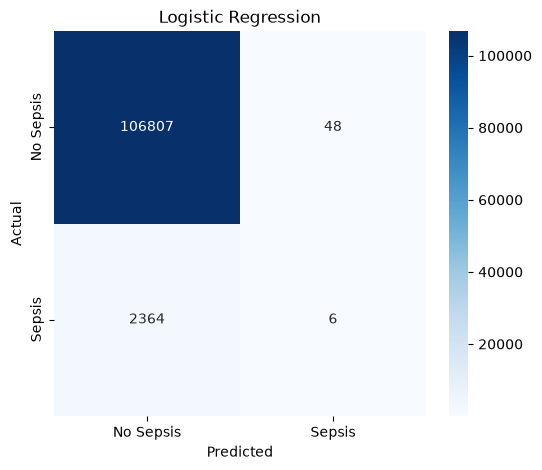

In [103]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Sepsis","Sepsis"],
    yticklabels=["No Sepsis","Sepsis"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")

plt.show()

In [104]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [105]:
dt_pred = dt_model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [106]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc = roc_auc_score(y_test, dt_pred)

print("Accuracy :", dt_accuracy)
print("Precision :", dt_precision)
print("Recall :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC Score :", dt_roc)

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

Accuracy : 0.9735317006179904
Precision : 0.3997691419776837
Recall : 0.4383966244725738
F1 Score : 0.4181927953310525
ROC-AUC Score : 0.7118987006130592

Classification Report
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99    106855
         1.0       0.40      0.44      0.42      2370

    accuracy                           0.97    109225
   macro avg       0.69      0.71      0.70    109225
weighted avg       0.97      0.97      0.97    109225



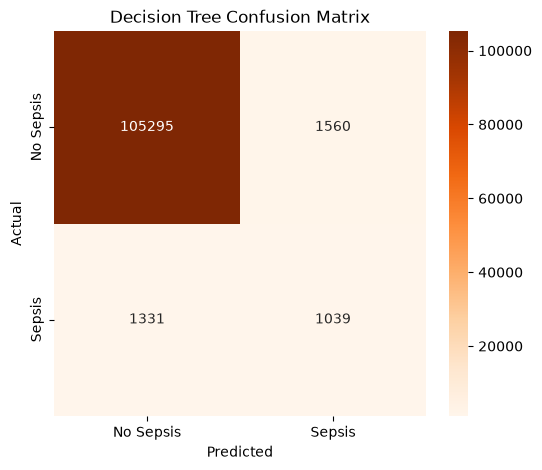

In [107]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Sepsis","Sepsis"],
    yticklabels=["No Sepsis","Sepsis"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [108]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [109]:
rf_pred = rf_model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [110]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc = roc_auc_score(y_test, rf_pred)

print("Accuracy :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC Score :", rf_roc)

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy : 0.9800686655985351
Precision : 0.897119341563786
Recall : 0.0919831223628692
F1 Score : 0.16685801760428626
ROC-AUC Score : 0.5458745802259342

Classification Report
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99    106855
         1.0       0.90      0.09      0.17      2370

    accuracy                           0.98    109225
   macro avg       0.94      0.55      0.58    109225
weighted avg       0.98      0.98      0.97    109225



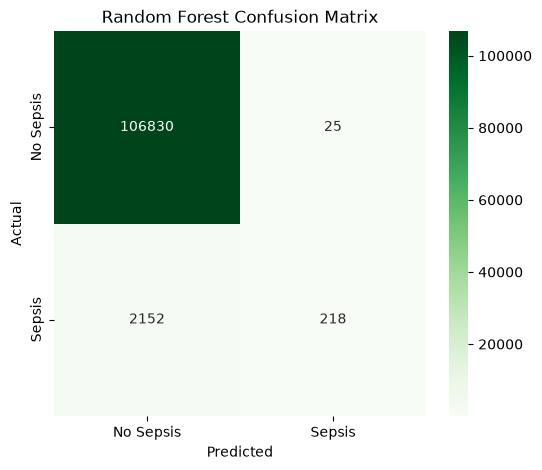

In [111]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Sepsis","Sepsis"],
    yticklabels=["No Sepsis","Sepsis"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

trained_models = {}

# Make a fixed copy of globals
all_objects = list(globals().items())

for name, obj in all_objects:

    if isinstance(obj, LogisticRegression):
        trained_models["Logistic Regression"] = obj

    elif isinstance(obj, DecisionTreeClassifier):
        trained_models["Decision Tree"] = obj

    elif isinstance(obj, RandomForestClassifier):
        trained_models["Random Forest"] = obj


# Check models found
print("Models found:", list(trained_models.keys()))

# Comparison
results = []

for name, model in trained_models.items():

    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, prediction),
        precision_score(y_test, prediction, zero_division=0),
        recall_score(y_test, prediction, zero_division=0),
        f1_score(y_test, prediction, zero_division=0),
        roc_auc_score(y_test, probability)
    ])


comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

display(comparison_df.round(4))

Models found: ['Logistic Regression', 'Decision Tree', 'Random Forest']


c:\Users\mjoth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\mjoth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9779,0.1111,0.0025,0.0050,0.7157
1,Decision Tree,0.9638,0.1943,0.2118,0.2027,0.5962
2,Random Forest,0.9801,0.8971,0.0920,0.1669,0.9532


In [113]:
log_prob = log_model.predict_proba(X_test)[:, 1]

dt_prob = dt_model.predict_proba(X_test)[:, 1]

rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [114]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

log_auc = roc_auc_score(y_test, log_prob)
dt_auc = roc_auc_score(y_test, dt_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

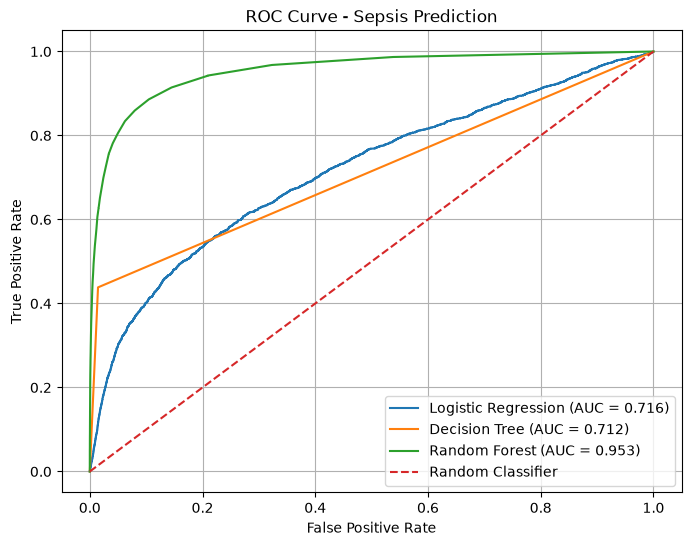

In [115]:
plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Sepsis Prediction")

plt.legend()
plt.grid()

plt.show()

In [116]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

        Feature  Importance
7           Age    0.172015
9        ICULOS    0.155336
10  HospAdmTime    0.113765
0            HR    0.093371
4           MAP    0.090463
3           SBP    0.088622
6          Resp    0.070968
5           DBP    0.065279
1         O2Sat    0.054650
2          Temp    0.050327
11      Glucose    0.026502
8        Gender    0.018703


In [117]:
import pandas as pd
import joblib
model = joblib.load("sepsis_model.pkl")
new_patient = pd.DataFrame({
    "HR": [85],
    "O2Sat": [97],
    "Temp": [37.2],
    "SBP": [120],
    "MAP": [85],
    "DBP": [75],
    "Resp": [18],
    "Age": [45],
    "Gender": [1],
    "ICULOS": [5],
    "HospAdmTime": [-2],
    "Glucose": [110]
})

print(new_patient)
new_patient = pd.DataFrame(
    imputer.transform(new_patient),
    columns=new_patient.columns
)


new_patient = pd.DataFrame(
    scaler.transform(new_patient),
    columns=new_patient.columns
)


   HR  O2Sat  Temp  SBP  MAP  DBP  Resp  Age  Gender  ICULOS  HospAdmTime  \
0  85     97  37.2  120   85   75    18   45       1       5           -2   

   Glucose  
0      110  


In [118]:
prediction = model.predict(new_patient)

print("Prediction Value:", prediction[0])

Prediction Value: 0.0


In [119]:
probability = model.predict_proba(new_patient)

print(probability)

[[0.78 0.22]]


In [120]:
# =====================================================
# UNCERTAINTY-AWARE SEPSIS PREDICTION SYSTEM
# =====================================================

import numpy as np

# -----------------------------------------------------
# STEP 1: USE THE TRAINED RANDOM FOREST MODEL
# -----------------------------------------------------

model = rf_model


# -----------------------------------------------------
# STEP 2: PREDICT SEPSIS
# -----------------------------------------------------

# 0 = No Sepsis
# 1 = Sepsis

prediction = model.predict(new_patient)[0]


# -----------------------------------------------------
# STEP 3: GET PREDICTION PROBABILITIES
# -----------------------------------------------------

probabilities = model.predict_proba(new_patient)[0]

no_sepsis_probability = probabilities[0]

sepsis_probability = probabilities[1]


# -----------------------------------------------------
# STEP 4: CONVERT PREDICTION TO TEXT
# -----------------------------------------------------

if prediction == 1:

    prediction_result = "SEPSIS DETECTED"

else:

    prediction_result = "NO SEPSIS DETECTED"


# -----------------------------------------------------
# STEP 5: CALCULATE RISK SCORE
# -----------------------------------------------------

risk_score = sepsis_probability * 100


# -----------------------------------------------------
# STEP 6: RISK STRATIFICATION
# -----------------------------------------------------

if risk_score < 20:

    risk_level = "Low Risk"

elif risk_score < 50:

    risk_level = "Moderate Risk"

elif risk_score < 80:

    risk_level = "High Risk"

else:

    risk_level = "Critical Risk"


# -----------------------------------------------------
# STEP 7: GET PREDICTIONS FROM ALL RANDOM FOREST TREES
# -----------------------------------------------------

# Convert DataFrame to NumPy array
# This prevents the feature-name warning

new_patient_array = new_patient.to_numpy()

tree_predictions = []

for tree in model.estimators_:

    tree_prediction = tree.predict(
        new_patient_array
    )[0]

    tree_predictions.append(
        int(tree_prediction)
    )


# Convert the predictions to a NumPy array

tree_predictions = np.array(
    tree_predictions
)


# -----------------------------------------------------
# STEP 8: COUNT THE TREE VOTES
# -----------------------------------------------------

sepsis_tree_count = np.sum(
    tree_predictions == 1
)

no_sepsis_tree_count = np.sum(
    tree_predictions == 0
)

total_trees = len(
    tree_predictions
)


# -----------------------------------------------------
# STEP 9: CALCULATE TREE AGREEMENT
# -----------------------------------------------------

if prediction == 1:

    agreement_score = (
        sepsis_tree_count /
        total_trees
    ) * 100

else:

    agreement_score = (
        no_sepsis_tree_count /
        total_trees
    ) * 100


# -----------------------------------------------------
# STEP 10: CALCULATE UNCERTAINTY SCORE
# -----------------------------------------------------

uncertainty_score = (
    100 - agreement_score
)


# -----------------------------------------------------
# STEP 11: ASSIGN UNCERTAINTY LEVEL
# -----------------------------------------------------

if uncertainty_score < 10:

    uncertainty_level = (
        "Very Low Uncertainty"
    )

elif uncertainty_score < 25:

    uncertainty_level = (
        "Low Uncertainty"
    )

elif uncertainty_score < 40:

    uncertainty_level = (
        "Moderate Uncertainty"
    )

else:

    uncertainty_level = (
        "High Uncertainty"
    )


# -----------------------------------------------------
# STEP 12: CLINICAL REVIEW FLAG
# -----------------------------------------------------

if uncertainty_score >= 40:

    clinical_review = (
        "CLINICAL REVIEW REQUIRED"
    )

    review_action = (
        "The model prediction has high "
        "uncertainty. Verify the patient "
        "measurements and perform additional "
        "clinical assessment."
    )

else:

    clinical_review = (
        "PREDICTION ACCEPTABLE"
    )

    review_action = (
        "The model prediction has sufficient "
        "tree agreement. Continue with "
        "risk-based monitoring."
    )


# -----------------------------------------------------
# STEP 13: AUTOMATED RISK-BASED ALERT
# -----------------------------------------------------

if risk_level == "Low Risk":

    alert = "NO ALERT"

    action = (
        "Continue routine patient monitoring."
    )


elif risk_level == "Moderate Risk":

    alert = "WARNING ALERT"

    action = (
        "Increase the frequency of "
        "patient monitoring."
    )


elif risk_level == "High Risk":

    alert = "URGENT ALERT"

    action = (
        "Notify the healthcare provider "
        "for clinical assessment."
    )


else:

    alert = "CRITICAL ALERT"

    action = (
        "Immediate clinical assessment "
        "and urgent intervention are "
        "recommended."
    )


# -----------------------------------------------------
# STEP 14: DISPLAY THE COMPLETE RESULT
# -----------------------------------------------------

print("\n========================================")

print(
    " UNCERTAINTY-AWARE SEPSIS PREDICTION"
)

print("========================================")

print()

print(
    "Prediction:",
    prediction_result
)

print(
    "No-Sepsis Probability:",
    round(
        no_sepsis_probability * 100,
        2
    ),
    "%"
)

print(
    "Sepsis Probability:",
    round(
        sepsis_probability * 100,
        2
    ),
    "%"
)

print(
    "Risk Score:",
    round(
        risk_score,
        2
    ),
    "%"
)

print(
    "Risk Level:",
    risk_level
)

print()

print(
    "Sepsis Tree Votes:",
    sepsis_tree_count
)

print(
    "No-Sepsis Tree Votes:",
    no_sepsis_tree_count
)

print(
    "Total Trees:",
    total_trees
)

print(
    "Tree Agreement Score:",
    round(
        agreement_score,
        2
    ),
    "%"
)

print(
    "Uncertainty Score:",
    round(
        uncertainty_score,
        2
    ),
    "%"
)

print(
    "Uncertainty Level:",
    uncertainty_level
)

print()

print(
    "Clinical Review Status:",
    clinical_review
)

print()

print(
    "Alert:",
    alert
)

print()

print(
    "Recommended Action:"
)

print(
    action
)

print()

print(
    "Review Recommendation:"
)

print(
    review_action
)

print("========================================")


 UNCERTAINTY-AWARE SEPSIS PREDICTION

Prediction: NO SEPSIS DETECTED
No-Sepsis Probability: 99.0 %
Sepsis Probability: 1.0 %
Risk Score: 1.0 %
Risk Level: Low Risk

Sepsis Tree Votes: 1
No-Sepsis Tree Votes: 99
Total Trees: 100
Tree Agreement Score: 99.0 %
Uncertainty Score: 1.0 %
Uncertainty Level: Very Low Uncertainty

Clinical Review Status: PREDICTION ACCEPTABLE

Alert: NO ALERT

Recommended Action:
Continue routine patient monitoring.

Review Recommendation:
The model prediction has sufficient tree agreement. Continue with risk-based monitoring.


In [121]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)
print("X_test shape:", X_test.shape)
print("rf_model:", rf_model)

SHAP version: 0.52.0
X_test shape: (109225, 12)
rf_model: RandomForestClassifier(random_state=42)


In [122]:
X_shap = X_test.iloc[:30].copy()

print("X_shap shape:", X_shap.shape)

X_shap shape: (30, 12)


In [123]:
explainer = shap.TreeExplainer(rf_model)

print("Explainer created successfully")

Explainer created successfully


In [124]:
shap_exp = explainer(X_shap)

print("SHAP explanation created")
print("SHAP values shape:", shap_exp.values.shape)

SHAP explanation created
SHAP values shape: (30, 12, 2)


In [125]:
values = shap_exp.values

print("Original SHAP shape:", values.shape)

if values.ndim == 3:
    # Select class 1 = Sepsis
    values = values[:, :, 1]

elif values.ndim == 2:
    # Already in correct format
    values = values

else:
    raise ValueError(
        f"Unexpected SHAP dimensions: {values.shape}"
    )

print("Final SHAP shape:", values.shape)
print("X_shap shape:", X_shap.shape)

Original SHAP shape: (30, 12, 2)
Final SHAP shape: (30, 12)
X_shap shape: (30, 12)


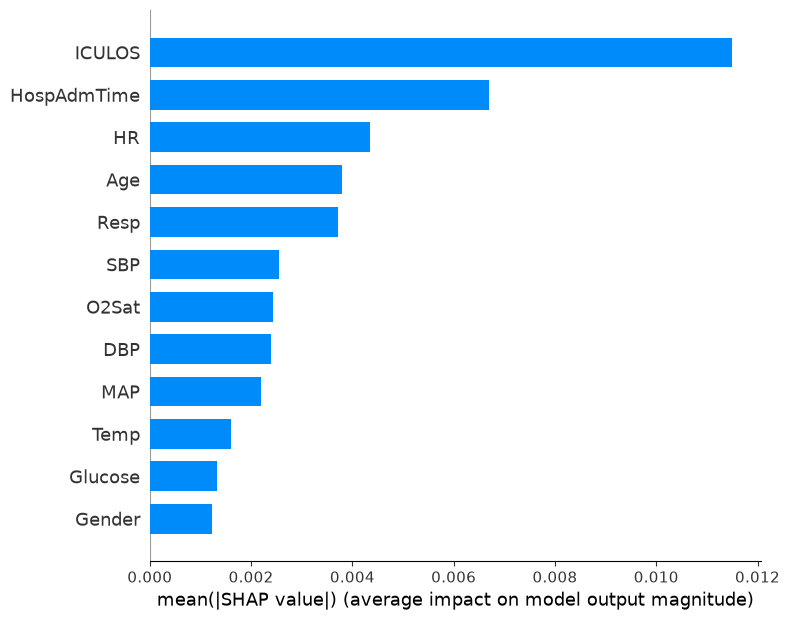

In [126]:
shap.summary_plot(
    values,
    X_shap,
    feature_names=X_shap.columns,
    plot_type="bar",
    max_display=12
)

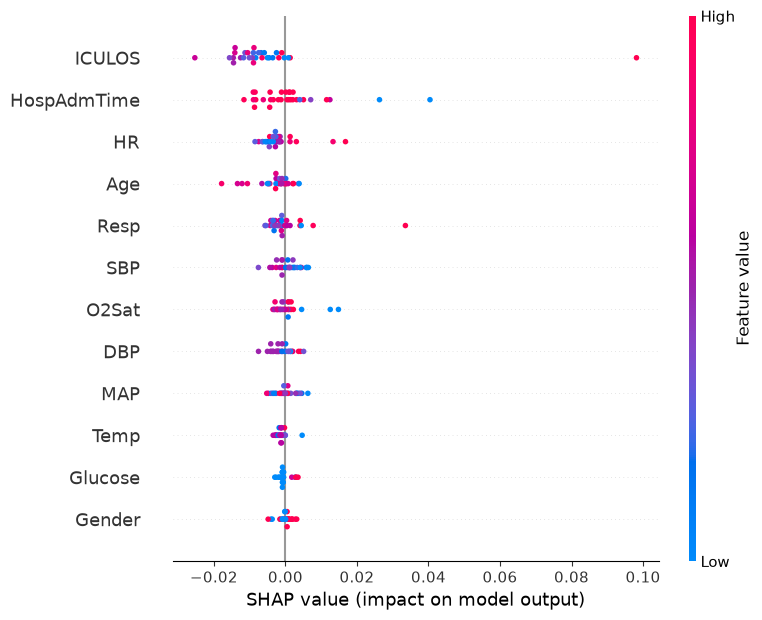

In [127]:
shap.summary_plot(
    values,
    X_shap,
    feature_names=X_shap.columns,
    max_display=12
)

In [128]:
import pandas as pd

patient_history = pd.DataFrame({
    "Time_Hour": [0, 2, 4, 6],

    "HR": [85, 92, 101, 110],
    "O2Sat": [98, 96, 94, 91],
    "Temp": [37.0, 37.5, 38.1, 38.8],
    "SBP": [120, 115, 105, 95],
    "MAP": [85, 80, 74, 65],
    "DBP": [75, 72, 68, 60],
    "Resp": [18, 20, 23, 27],
    "Age": [45, 45, 45, 45],
    "Gender": [1, 1, 1, 1],
    "ICULOS": [1, 3, 5, 7],
    "HospAdmTime": [-2, -2, -2, -2],
    "Glucose": [110, 118, 130, 145]
})

print(patient_history)

   Time_Hour   HR  O2Sat  Temp  SBP  MAP  DBP  Resp  Age  Gender  ICULOS  \
0          0   85     98  37.0  120   85   75    18   45       1       1   
1          2   92     96  37.5  115   80   72    20   45       1       3   
2          4  101     94  38.1  105   74   68    23   45       1       5   
3          6  110     91  38.8   95   65   60    27   45       1       7   

   HospAdmTime  Glucose  
0           -2      110  
1           -2      118  
2           -2      130  
3           -2      145  


In [129]:
model_features = patient_history.drop(
    "Time_Hour",
    axis=1
)

patient_imputed = pd.DataFrame(
    imputer.transform(model_features),
    columns=model_features.columns
)

patient_scaled = pd.DataFrame(
    scaler.transform(patient_imputed),
    columns=model_features.columns
)

risk_probability = rf_model.predict_proba(
    patient_scaled
)[:, 1]

patient_history["Risk"] = (
    risk_probability * 100
)

print(
    patient_history[
        ["Time_Hour", "Risk"]
    ]
)

   Time_Hour  Risk
0          0   2.0
1          2   0.0
2          4   3.0
3          6   7.0


In [130]:
patient_history["Risk_Change"] = (
    patient_history["Risk"].diff()
)

patient_history["Risk_Rate"] = (
    patient_history["Risk"].diff()
    /
    patient_history["Time_Hour"].diff()
)

current_risk = patient_history["Risk"].iloc[-1]

recent_rate = patient_history["Risk_Rate"].iloc[-1]

print(
    patient_history[
        ["Time_Hour", "Risk", "Risk_Rate"]
    ]
)

print("Current Risk:", round(current_risk, 2), "%")
print("Risk Change Rate:", round(recent_rate, 2), "% per hour")

   Time_Hour  Risk  Risk_Rate
0          0   2.0        NaN
1          2   0.0       -1.0
2          4   3.0        1.5
3          6   7.0        2.0
Current Risk: 7.0 %
Risk Change Rate: 2.0 % per hour


In [131]:
from sklearn.linear_model import LinearRegression
import numpy as np

X_time = patient_history[["Time_Hour"]]

y_risk = patient_history["Risk"]

forecast_model = LinearRegression()

forecast_model.fit(
    X_time,
    y_risk
)

future = pd.DataFrame({
    "Time_Hour": [8, 10, 12]
})

future["Forecasted_Risk"] = forecast_model.predict(
    future[["Time_Hour"]]
)

future["Forecasted_Risk"] = np.clip(
    future["Forecasted_Risk"],
    0,
    100
)

print(future)

   Time_Hour  Forecasted_Risk
0          8              7.5
1         10              9.3
2         12             11.1


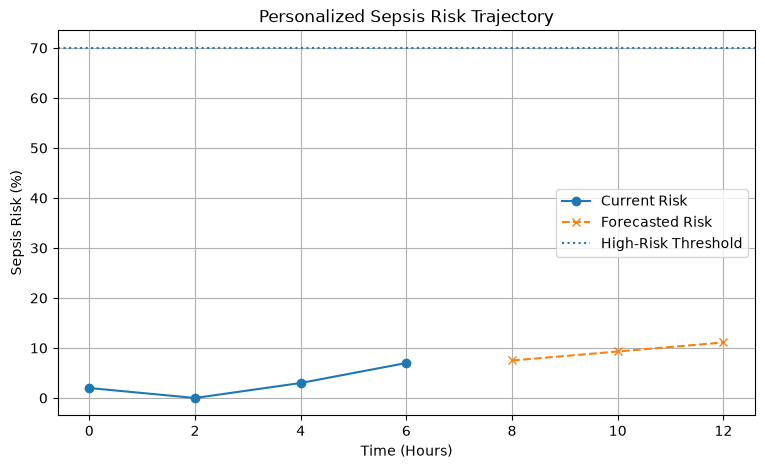

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    patient_history["Time_Hour"],
    patient_history["Risk"],
    marker="o",
    label="Current Risk"
)

plt.plot(
    future["Time_Hour"],
    future["Forecasted_Risk"],
    marker="x",
    linestyle="--",
    label="Forecasted Risk"
)

plt.axhline(
    70,
    linestyle=":",
    label="High-Risk Threshold"
)

plt.xlabel("Time (Hours)")
plt.ylabel("Sepsis Risk (%)")

plt.title(
    "Personalized Sepsis Risk Trajectory"
)

plt.legend()
plt.grid(True)

plt.show()

In [133]:
import pandas as pd
import numpy as np

def data_reliability_check(patient):
    
    total_checks = 0
    failed_checks = 0
    problems = []

    # -----------------------------------
    # 1. Missing value check
    # -----------------------------------
    for feature in patient.index:
        total_checks += 1
        
        value = patient[feature]
        
        if pd.isna(value):
            failed_checks += 1
            problems.append(f"Missing value: {feature}")

    # -----------------------------------
    # 2. Physiological range checks
    # -----------------------------------
    ranges = {
        "HR": (30, 220),
        "O2Sat": (50, 100),
        "Temp": (30, 43),
        "SBP": (50, 250),
        "MAP": (30, 180),
        "DBP": (20, 150),
        "Resp": (5, 60),
        "Age": (0, 120),
        "Glucose": (20, 600)
    }

    for feature, (minimum, maximum) in ranges.items():

        if feature in patient.index:

            total_checks += 1

            value = patient[feature]

            if not pd.isna(value):

                if value < minimum or value > maximum:
                    failed_checks += 1
                    problems.append(
                        f"Unusual value: {feature} = {value}"
                    )

    # -----------------------------------
    # 3. Blood pressure consistency
    # -----------------------------------
    if all(x in patient.index for x in ["SBP", "DBP", "MAP"]):

        total_checks += 1

        sbp = patient["SBP"]
        dbp = patient["DBP"]
        map_value = patient["MAP"]

        if not any(pd.isna([sbp, dbp, map_value])):

            expected_map = (sbp + 2 * dbp) / 3

            difference = abs(map_value - expected_map)

            if difference > 15:
                failed_checks += 1
                problems.append(
                    "SBP/DBP/MAP values are inconsistent"
                )

    # -----------------------------------
    # 4. Oxygen saturation check
    # -----------------------------------
    if "O2Sat" in patient.index:

        total_checks += 1

        if not pd.isna(patient["O2Sat"]):

            if patient["O2Sat"] < 70:
                failed_checks += 1
                problems.append(
                    "Extremely low oxygen saturation"
                )

    # -----------------------------------
    # 5. Calculate reliability
    # -----------------------------------
    if total_checks > 0:

        reliability = (
            1 - failed_checks / total_checks
        ) * 100

    else:
        reliability = 0

    reliability = round(
        max(0, min(100, reliability)), 2
    )

    # -----------------------------------
    # 6. Reliability level
    # -----------------------------------
    if reliability >= 90:
        level = "HIGH RELIABILITY"

    elif reliability >= 75:
        level = "MODERATE RELIABILITY"

    else:
        level = "LOW RELIABILITY"

    return reliability, level, problems

In [134]:
patient = X_test.iloc[0]

reliability, level, problems = data_reliability_check(patient)

print("========================================")
print("PATIENT DATA RELIABILITY")
print("========================================")

print("Data Reliability Score:", reliability, "%")
print("Reliability Level:", level)

if problems:
    print("\nDetected Problems:")
    
    for problem in problems:
        print("-", problem)

else:
    print("\nNo major data quality problems detected.")

print("========================================")

PATIENT DATA RELIABILITY
Data Reliability Score: 56.52 %
Reliability Level: LOW RELIABILITY

Detected Problems:
- Unusual value: HR = -0.6677646809324572
- Unusual value: O2Sat = 0.9597461864773761
- Unusual value: Temp = 0.023589626602688717
- Unusual value: SBP = -1.1242832458153333
- Unusual value: MAP = -0.46741073061863403
- Unusual value: DBP = 0.10145895074245322
- Unusual value: Resp = -0.5231680473714864
- Unusual value: Age = -0.28472885089081496
- Unusual value: Glucose = -0.06505013895379053
- Extremely low oxygen saturation


In [135]:
patient = X_test.iloc[0]

# -------------------------------
# Data reliability
# -------------------------------
reliability, reliability_level, problems = \
    data_reliability_check(patient)

# -------------------------------
# Sepsis prediction
# -------------------------------
prediction = rf_model.predict(
    patient.to_frame().T
)[0]

probability = rf_model.predict_proba(
    patient.to_frame().T
)[0][1]

# -------------------------------
# Display
# -------------------------------
print("========================================")
print("SEPSIS PREDICTION + DATA RELIABILITY")
print("========================================")

if prediction == 1:
    print("Prediction: SEPSIS DETECTED")
else:
    print("Prediction: NO SEPSIS DETECTED")

print("Sepsis Probability:",
      round(probability * 100, 2), "%")

print("----------------------------------------")

print("Data Reliability Score:",
      reliability, "%")

print("Reliability Level:",
      reliability_level)

print("----------------------------------------")

if problems:

    print("Data Quality Warnings:")

    for problem in problems:
        print("-", problem)

else:

    print("Data Quality Status: GOOD")

print("========================================")

SEPSIS PREDICTION + DATA RELIABILITY
Prediction: NO SEPSIS DETECTED
Sepsis Probability: 0.0 %
----------------------------------------
Data Reliability Score: 56.52 %
Reliability Level: LOW RELIABILITY
----------------------------------------
Data Quality Warnings:
- Unusual value: HR = -0.6677646809324572
- Unusual value: O2Sat = 0.9597461864773761
- Unusual value: Temp = 0.023589626602688717
- Unusual value: SBP = -1.1242832458153333
- Unusual value: MAP = -0.46741073061863403
- Unusual value: DBP = 0.10145895074245322
- Unusual value: Resp = -0.5231680473714864
- Unusual value: Age = -0.28472885089081496
- Unusual value: Glucose = -0.06505013895379053
- Extremely low oxygen saturation
